# Week 3 Day 2 — Overfitting in Trees + Pruning

## What I built:
- Visualized overfitting — train vs val accuracy across depths 1-20
- Cost complexity pruning — found best alpha using pruning path
- Compared 3 trees on Titanic dataset

## Key concepts:

**Overfitting in trees:**
- No depth limit → train accuracy 100%, val accuracy drops
- Tree memorises every training sample including noise
- Best depth = where val accuracy peaks before dropping

**Pre-pruning:**
- max_depth → stop growing at certain depth
- min_samples_split → don't split if fewer than N samples
- Faster, simpler, set before training

**Post-pruning (cost complexity):**
- Grow full tree then remove nodes using alpha
- Tree Score = SSR + alpha × number of leaves
- Higher alpha → smaller tree → less overfitting
- Best alpha found using cross validation

## Results — Titanic:
No limit (overfit)  : 0.7823 ← worst
max_depth=3         : 0.8193 ← best
ccp_alpha=0.014     : 0.8058 ← good

Decision Tree (0.8193) beats Logistic Regression (0.8114)
Trees capture non-linear patterns LR cannot.

# Demonstrate overfitting visually:

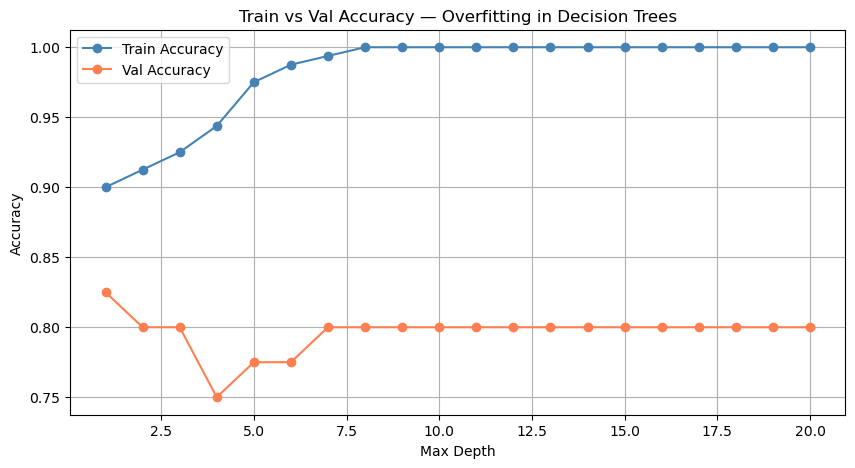

Best depth     : 1
Best val score : 0.8250


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=200, n_features=2, 
                           n_informative=2, n_redundant=0,
                           random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#loop through depths 1 to 20
depths = list(range(1,21))
train_scores = []
val_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    val_scores.append(tree.score(X_val, y_val))

# plot
plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, label='Train Accuracy', color='steelblue', marker='o')
plt.plot(depths, val_scores,   label='Val Accuracy',   color='coral',     marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Train vs Val Accuracy — Overfitting in Decision Trees')
plt.legend()
plt.grid(True)
plt.savefig('overfitting_tree.png', dpi=150, bbox_inches='tight')
plt.show()

best_depth = depths[np.argmax(val_scores)]
print(f"Best depth     : {best_depth}")
print(f"Best val score : {max(val_scores):.4f}")

# Cost complexity pruning:

Number of alphas found: 11
Alpha range: 0.000000 to 0.321883


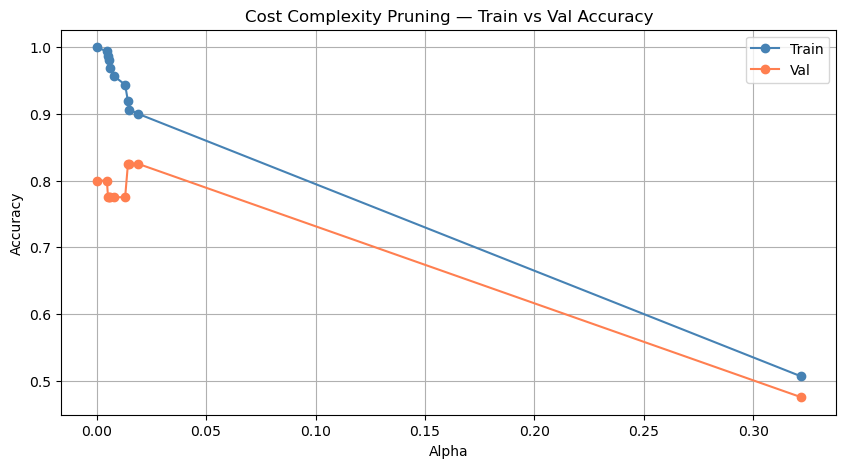

Best alpha     : 0.014312
Best val score : 0.8250


In [2]:
# get all alpha values
tree_full = DecisionTreeClassifier(random_state=42)
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas

print(f"Number of alphas found: {len(alphas)}")
print(f"Alpha range: {alphas[0]:.6f} to {alphas[-1]:.6f}")

# train one tree per alpha
train_scores_ccp = []
val_scores_ccp   = []

for alpha in alphas:
    tree = DecisionTreeClassifier(ccp_alpha = alpha, random_state = 42)
    tree.fit(X_train, y_train)
    train_scores_ccp.append(tree.score(X_train, y_train))
    val_scores_ccp.append(tree.score(X_val, y_val))

# plot
plt.figure(figsize=(10, 5))
plt.plot(alphas, train_scores_ccp, label='Train', color='steelblue', marker='o')
plt.plot(alphas, val_scores_ccp,   label='Val',   color='coral',     marker='o')
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.title('Cost Complexity Pruning — Train vs Val Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('pruning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

best_alpha = alphas[np.argmax(val_scores_ccp)]
print(f"Best alpha     : {best_alpha:.6f}")
print(f"Best val score : {max(val_scores_ccp):.4f}")

# Apply best pruning to Titanic:

In [3]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold

df = pd.read_csv('train.csv')

# feature engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['Title']      = df['Name'].apply(
                       lambda name: name.split(',')[1]
                                        .split('.')[0].strip())
df['Title']      = df['Title'].map({
                       'Mr': 0, 'Miss': 1, 'Mrs': 2,
                       'Master': 3}).fillna(4)

num_cols = ['Age', 'Fare', 'FamilySize', 'Title']
cat_cols = ['Sex', 'Embarked', 'Pclass']

X = df[num_cols + cat_cols]
y = df['Survived']

# preprocessor
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# compare 3 trees
skfold = StratifiedKFold(n_splits=5)

trees = {
    'No limit (overfit)'  : DecisionTreeClassifier(random_state=42),
    'max_depth=3'         : DecisionTreeClassifier(max_depth=3, random_state=42),
    'ccp_alpha=0.014'     : DecisionTreeClassifier(ccp_alpha=0.014, random_state=42)
}

print("=" * 50)
print("   DECISION TREE COMPARISON — Titanic")
print("=" * 50)
for name, tree in trees.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', tree)])
    scores = cross_val_score(pipe, X, y, cv=skfold, scoring='accuracy')
    print(f"  {name:25} : {scores.mean():.4f} ± {scores.std():.4f}")
print("=" * 50)

   DECISION TREE COMPARISON — Titanic
  No limit (overfit)        : 0.7823 ± 0.0229
  max_depth=3               : 0.8193 ± 0.0261
  ccp_alpha=0.014           : 0.8058 ± 0.0296
